# Bầu Cua Expected Value and Simulation

This noteboook models the EV of a one-unit bet in Bầu cua using probability and Monte Carlo Simulation. Special thanks to Chú Joey for playing house and rinsing me once at Tết and inspiring this notebook. :) Though in that case this investigation wouldn't apply because of the kindness of family (he gave me my money back).

## 1. Rules

Rules:
- Three dice are rolled. Each dice has 6 symbols: nui (deer), bầu (gourd), gà (chicken), cá (fish), cua (crab), tôm (shrimp)
- A player places a bet on one symbol before the roll.
- If the chosen symbol doesn't appear, the player loses the stake. Otherwise, if the symbol appears k times, the player earns k units of profit.

We are assuming the three die are fair and independent.

## 2. Probability Model

Let X be the number of dice showing the chosen symbol.

Under the fair-dice assumption:

X ~ Binomial(3, 1/6)

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Payoffs
Let Y be the net profit from a one-unit bet.
| X | Outcome | Net profit \(Y\) |
|---:|---|---:|
| 0 | no match | -1 |
| 1 | one match | 1 |
| 2 | two matches | 2 |
| 3 | three matches | 3 |
## 4. EV Calculation

In [19]:
from math import comb

n, p = 3, 1/6

probabilities = {}

for i in range(n + 1):
    probabilities[i] = comb(n, i) * (p ** i) * ((1 - p) ** (n - i))

probabilities

{0: 0.5787037037037038,
 1: 0.34722222222222227,
 2: 0.06944444444444445,
 3: 0.0046296296296296285}

Here are the probabilities of each outcome. It is most likely to get 0 symbols shown, followed by 1, 2, then 3, which follows intuition. Also, we can see that the probabilities sum to 1. Lets continue by calculating the expected value, which we expect to be negative due to the distribution.

In [20]:
payoffs = {0: -1, 1: 1, 2: 2, 3: 3}

ev = 0

for i in range(4):
    ev += probabilities[i] * payoffs[i]

ev

-0.07870370370370379

We can see the EV is negative as expected, and the house edge is approximately -7.87%. This means for every one unit of betting you put down, you are expected to lose about 7.87% of it. In other words, for every $100 you wager, you are expected to lose $7.87. This is worse than shorting the S%P 500 (annual return adjusted for inflation), and you can execute this "investment" in about 10 seconds. Jokes aside, this is not a good bet. It doesn't necessarily mean you won't get lucky, for not every individual bet will lose money, but it describes the long-run average of the model.

## 5. Monte Carlo
Let's run a Monte Carlo simulation to verify our intuition and math get some practice before moving to some more interesting strategies.

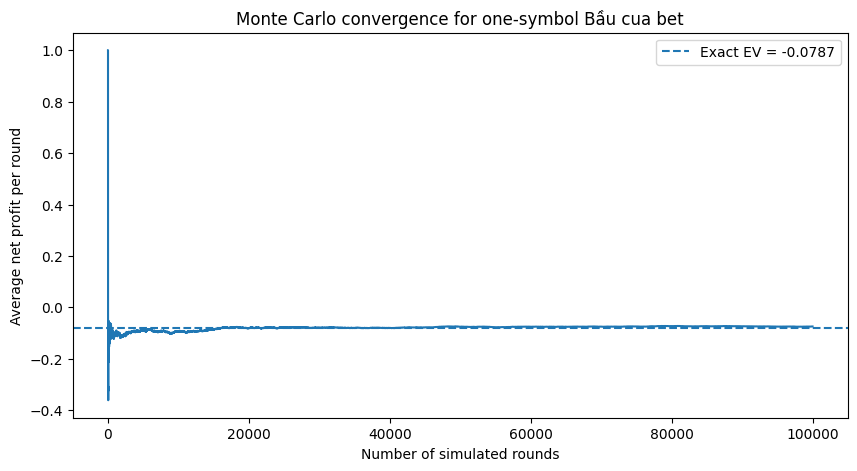

In [55]:
import random

def sim_single_symbol_bet(num_rounds):
    profits = []
    symbol = 0 # by symmetry, any fixed symbol has the same probability distribution

    for i in range(num_rounds):
        roll = [random.randint(0,5), random.randint(0,5), random.randint(0,5)]
        matches = 0
        for die in roll:
            if die == symbol:
                matches += 1
            
        if matches == 0:
            profits.append(-1)
        else: 
            profits.append(matches)
    
    return profits

profits = sim_single_symbol_bet(100_000)
running_avg = []
total = 0

for i, profit in enumerate(profits):
    total += profit
    running_avg.append(total / (i + 1))

round_numbers = range(1, len(running_avg) + 1)

plt.figure(figsize=(10, 5))
plt.plot(round_numbers, running_avg)
plt.axhline(ev, linestyle="--", label=f"Exact EV = {ev:.4f}")
plt.xlabel("Number of simulated rounds")
plt.ylabel("Average net profit per round")
plt.title("Monte Carlo convergence for one-symbol Bầu cua bet")
plt.legend()
plt.show()



The running average is pretty variable in the early rounds because each individual round can produce a gain or loss that is large relative to the expected value. But as the number of simulated rounds increases, these short-run fluctuations become less important, and the average net profit begins to stabilize. In this run, the simulated average approaches the exact expected value of approximately -0.0787 units per one-unit bet. The Monte Carlo simulation is consistent with the analytical model. Thus I was destined to lose money to Joey.